<a href="https://colab.research.google.com/github/MrCherveN/Machine-Learning--4-0_HomeTasks/blob/main/HW_2_3_%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D0%B0_%D0%BF%D1%80%D0%B8%D0%B9%D0%BD%D1%8F%D1%82%D1%82%D1%8F_%D1%80%D1%96%D1%88%D0%B5%D0%BD%D1%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



In [1]:
!pip install opendatasets --upgrade --quiet

In [2]:
import opendatasets as od
import pandas as pd
import numpy as np
import sys
import importlib
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, f1_score, auc, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree, export_text

In [3]:
!git clone https://github.com/MrCherveN/Machine-Learning--4-0_HomeTasks.git

fatal: destination path 'Machine-Learning--4-0_HomeTasks' already exists and is not an empty directory.


**Посилання** на файл "process_bank_churn" в репозиторії:

https://github.com/MrCherveN/Machine-Learning--4-0_HomeTasks/blob/main/process_bank_churn.py


In [4]:
sys.path.append('/content/Machine-Learning--4-0_HomeTasks')

import process_bank_churn
importlib.reload(process_bank_churn)
from process_bank_churn import preprocess_data, preprocess_new_data

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [5]:
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-4'
od.download(dataset_url)
data_dir = '/content/bank-customer-churn-prediction-dlu-course-c-4'
train_csv = data_dir + '/train.csv'

raw_df = pd.read_csv(train_csv)

Skipping, found downloaded files in "./bank-customer-churn-prediction-dlu-course-c-4" (use force=True to force download)


In [6]:
data = preprocess_data(raw_df)

In [7]:
X_train = data['train_X']
train_targets = data['train_y']
X_val = data['val_X']
val_targets = data['val_y']

In [8]:
model = DecisionTreeClassifier(random_state=42)

In [9]:
#Натренуйте дерево прийняття рішень з зафіксованим random_state і з рештою аргументів за замовченням.

%%time
model.fit(X_train, train_targets)

CPU times: user 73.4 ms, sys: 0 ns, total: 73.4 ms
Wall time: 105 ms


DecisionTreeClassifier(random_state=42)

In [10]:
#Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?


#Додатково реалізуємо пдірахунок та вивід метрики f1 та матриці невідповідностей
def evaluate_model(inputs, targets, model, name=''):
  preds = model.predict(inputs)

  #f1_score_ = f1_score(targets, preds, pos_label=1)
  #print(f"F1 score {name}: {f1_score_:.2f}")

  y_pred_proba = model.predict_proba(inputs)
  y_pred_proba_1 = y_pred_proba[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba_1, pos_label=1)

  # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  return preds, y_pred_proba, roc_auc


def predict_and_plot(targets, preds, name=''):

    cf = confusion_matrix(targets, preds, normalize='true')

    plt.figure()
    sns.heatmap(cf, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix (normalized)'.format(name))
    plt.show();



In [11]:
train_preds, train_probs, train_roc_auc = evaluate_model(X_train, train_targets, model, 'Training')

AUROC for Training: 1.00


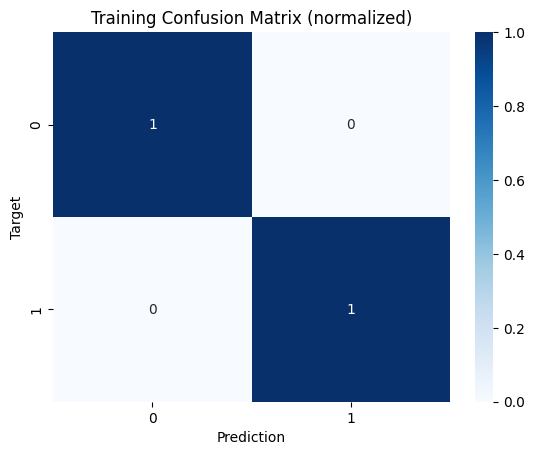

In [12]:
predict_and_plot(train_targets, train_preds, 'Training')

In [13]:
val_preds, val_probs, val_roc_auc  = evaluate_model(X_val, val_targets, model, 'Validation')

AUROC for Validation: 0.76


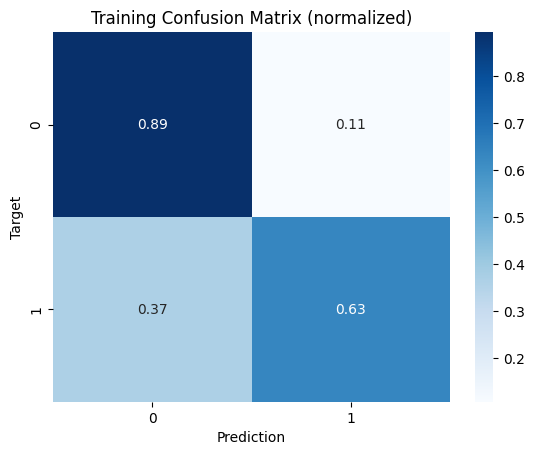

In [14]:
predict_and_plot(val_targets, val_preds, 'Training')

***Висновок:***

Результати метрик показують, що модель має перенавчання. Вона ідеально вивчила навчальні приклади, але не узагальнює валідаційні.

In [15]:
#Виведіть глибину дерева.
depth = model.tree_.max_depth
print(f"Глибина дерева: {depth}")

Глибина дерева: 25


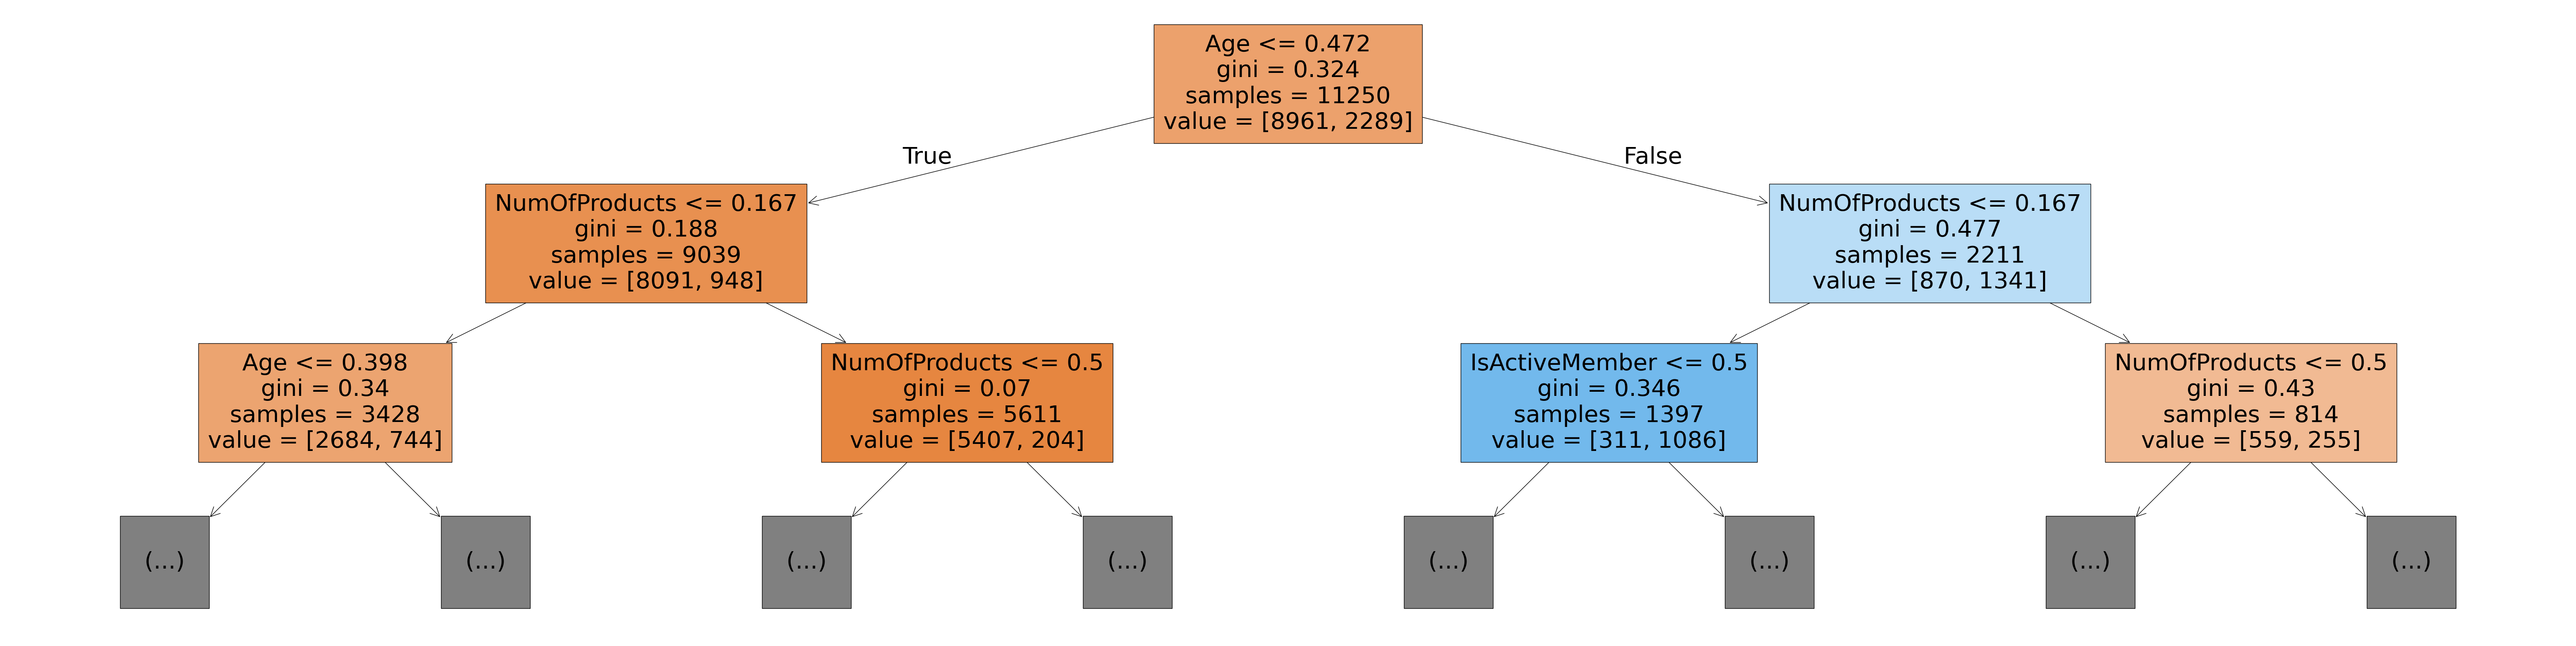

In [16]:
#Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, max_depth=2, filled=True);

In [17]:
tree_text = export_text(model, max_depth=2, feature_names=list(X_train.columns))
print(tree_text[:5000])

|--- Age <= 0.47
|   |--- NumOfProducts <= 0.17
|   |   |--- Age <= 0.40
|   |   |   |--- truncated branch of depth 23
|   |   |--- Age >  0.40
|   |   |   |--- truncated branch of depth 20
|   |--- NumOfProducts >  0.17
|   |   |--- NumOfProducts <= 0.50
|   |   |   |--- truncated branch of depth 22
|   |   |--- NumOfProducts >  0.50
|   |   |   |--- truncated branch of depth 7
|--- Age >  0.47
|   |--- NumOfProducts <= 0.17
|   |   |--- IsActiveMember <= 0.50
|   |   |   |--- truncated branch of depth 16
|   |   |--- IsActiveMember >  0.50
|   |   |   |--- truncated branch of depth 16
|   |--- NumOfProducts >  0.17
|   |   |--- NumOfProducts <= 0.50
|   |   |   |--- truncated branch of depth 18
|   |   |--- NumOfProducts >  0.50
|   |   |   |--- class: 1.0



***Висновок:***

Ознаки, що є найвпливовішими для model з max_depth=2:
- Age
- NumOfProducts
- IsActiveMember


In [18]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

importance_df.head(10).style.background_gradient(subset='importance', cmap='Blues_r')

,feature,importance
1,Age,0.346301
4,NumOfProducts,0.167947
7,EstimatedSalary,0.131605
0,CreditScore,0.117156
3,Balance,0.081201
2,Tenure,0.061639
6,IsActiveMember,0.033070
9,Geography_Germany,0.015503
5,HasCrCard,0.014113
11,Gender_Female,0.009814


In [19]:
model_2 = DecisionTreeClassifier(max_depth=2, random_state=42)

In [20]:
%%time
model_2.fit(X_train, train_targets)

CPU times: user 16.9 ms, sys: 893 µs, total: 17.8 ms
Wall time: 18.9 ms


DecisionTreeClassifier(max_depth=2, random_state=42)

In [21]:
_, _, train_roc_auc = evaluate_model(X_train, train_targets, model_2, 'Training')

AUROC for Training: 0.84


In [22]:
_, _, val_roc_auc  = evaluate_model(X_val, val_targets, model_2, 'Validation')

AUROC for Validation: 0.85


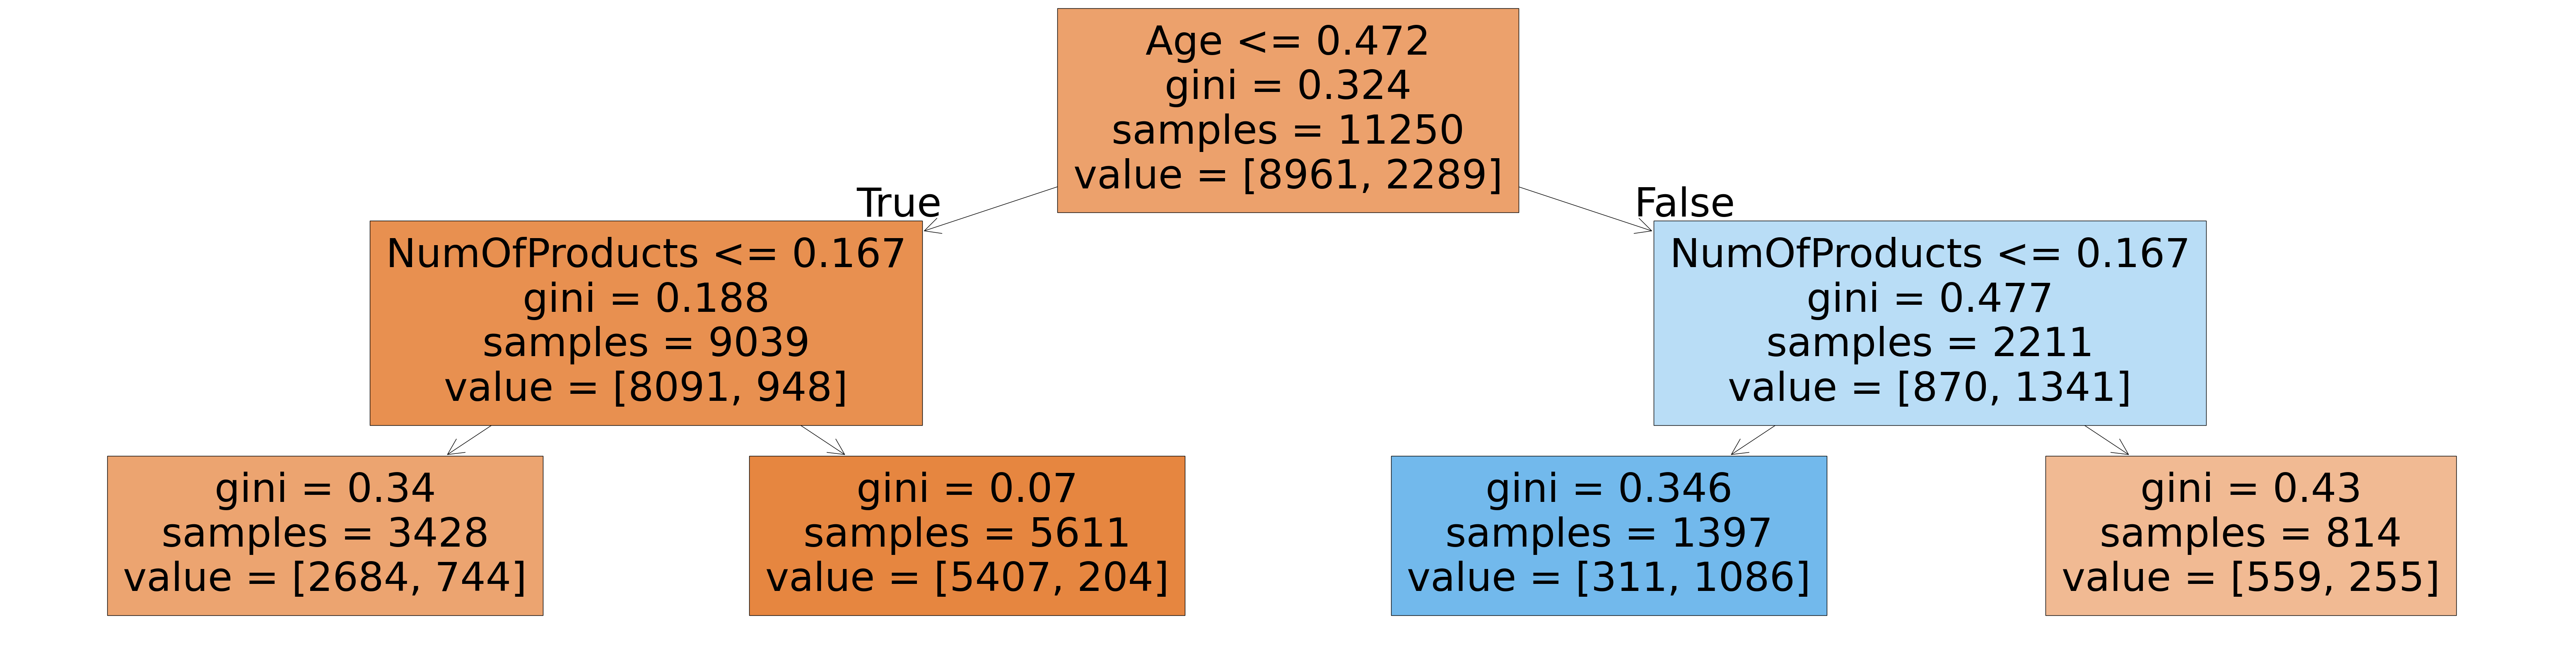

In [23]:
plt.figure(figsize=(80,20))
plot_tree(model_2, feature_names=X_train.columns, filled=True);

In [24]:
tree_text = export_text(model_2, feature_names=list(X_train.columns))
print(tree_text[:5000])

|--- Age <= 0.47
|   |--- NumOfProducts <= 0.17
|   |   |--- class: 0.0
|   |--- NumOfProducts >  0.17
|   |   |--- class: 0.0
|--- Age >  0.47
|   |--- NumOfProducts <= 0.17
|   |   |--- class: 1.0
|   |--- NumOfProducts >  0.17
|   |   |--- class: 0.0



In [25]:
importance_df_2 = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_2.feature_importances_
}).sort_values('importance', ascending=False)

importance_df_2.head(10).style.background_gradient(subset='importance', cmap='Blues_r')

,feature,importance
1,Age,0.712644
4,NumOfProducts,0.287356
0,CreditScore,0.000000
2,Tenure,0.000000
3,Balance,0.000000
5,HasCrCard,0.000000
6,IsActiveMember,0.000000
7,EstimatedSalary,0.000000
8,Geography_France,0.000000
9,Geography_Germany,0.000000


***Висновок:***

Ознаки, що є найвпливовішими для model_2:
- Age
- NumOfProducts


**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [26]:
model_3 = DecisionTreeClassifier(max_depth=8, max_leaf_nodes=40, random_state=42)
model_3.fit(X_train, train_targets)


DecisionTreeClassifier(max_depth=8, max_leaf_nodes=40, random_state=42)

In [27]:
_, _, train_roc_auc = evaluate_model(X_train, train_targets, model_3, 'Training')

AUROC for Training: 0.93


In [28]:
_, _, val_roc_auc  = evaluate_model(X_val, val_targets, model_3, 'Validation')

AUROC for Validation: 0.92


**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [29]:
train_auroc_list = []
val_auroc_list = []
max_depths = range(1,21)

for md in max_depths:
  model = DecisionTreeClassifier(max_depth=md, random_state=42)
  model.fit(X_train, train_targets)

  print(f'\nmax_depth: {md}')

  _, _, train_roc_auc = evaluate_model(X_train, train_targets, model, 'Training')
  _, _, val_roc_auc  = evaluate_model(X_val, val_targets, model, 'Validation')

  train_auroc_list.append(train_roc_auc)
  val_auroc_list.append(val_roc_auc)




max_depth: 1
AUROC for Training: 0.74
AUROC for Validation: 0.74

max_depth: 2
AUROC for Training: 0.84
AUROC for Validation: 0.85

max_depth: 3
AUROC for Training: 0.90
AUROC for Validation: 0.89

max_depth: 4
AUROC for Training: 0.91
AUROC for Validation: 0.91

max_depth: 5
AUROC for Training: 0.93
AUROC for Validation: 0.92

max_depth: 6
AUROC for Training: 0.93
AUROC for Validation: 0.92

max_depth: 7
AUROC for Training: 0.94
AUROC for Validation: 0.92

max_depth: 8
AUROC for Training: 0.95
AUROC for Validation: 0.90

max_depth: 9
AUROC for Training: 0.96
AUROC for Validation: 0.87

max_depth: 10
AUROC for Training: 0.97
AUROC for Validation: 0.85

max_depth: 11
AUROC for Training: 0.98
AUROC for Validation: 0.84

max_depth: 12
AUROC for Training: 0.99
AUROC for Validation: 0.82

max_depth: 13
AUROC for Training: 0.99
AUROC for Validation: 0.81

max_depth: 14
AUROC for Training: 1.00
AUROC for Validation: 0.79

max_depth: 15
AUROC for Training: 1.00
AUROC for Validation: 0.78

max

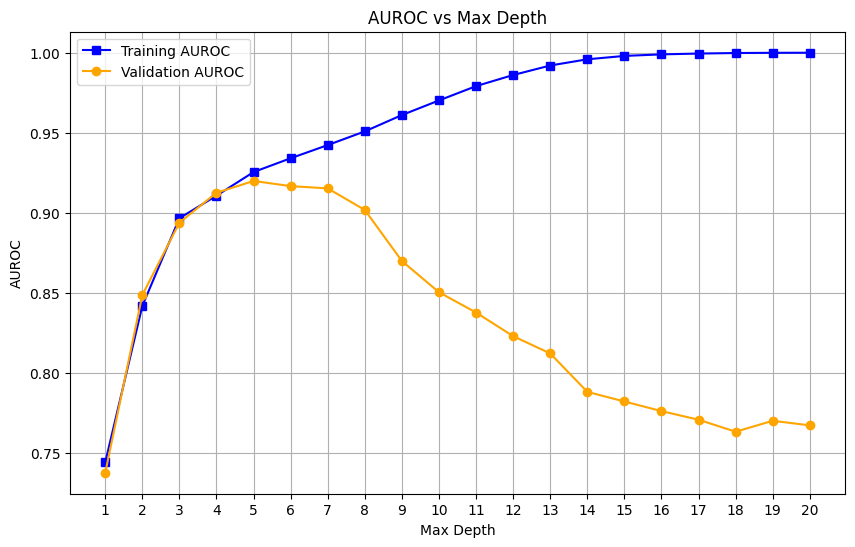

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(max_depths, train_auroc_list, 's-', label='Training AUROC', color='blue')
plt.plot(max_depths, val_auroc_list, 'o-', label='Validation AUROC', color='orange')

plt.title('AUROC vs Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('AUROC')
plt.xticks(max_depths)
plt.legend()
plt.grid(True)
plt.show()

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [31]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, train_targets)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [32]:
test_raw_df = pd.read_csv('/content/bank-customer-churn-prediction-dlu-course-c-4/test.csv')

In [33]:
inputs = preprocess_new_data(test_raw_df, data['imputer_num'], data['imputer_cat'], data['encoder'], data['scaler'], data['numeric_cols'], data['categorical_cols'])
test_preds = model.predict(inputs)
test_proba = model.predict_proba(inputs)[:, 1]

test_raw_df['Exited'] = test_proba
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.218962
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.028833
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.028833
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.759434
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.028833


In [34]:
submission_df = pd.read_csv('/content/bank-customer-churn-prediction-dlu-course-c-4/sample_submission.csv')
submission_df.head()

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [35]:
submission_df['Exited'] = test_raw_df['Exited']
submission_df.head()

,id,Exited
0,15000,0.218962
1,15001,0.028833
2,15002,0.028833
3,15003,0.759434
4,15004,0.028833


In [36]:
submission_df.to_csv('submission_log_reg.csv', index=False)

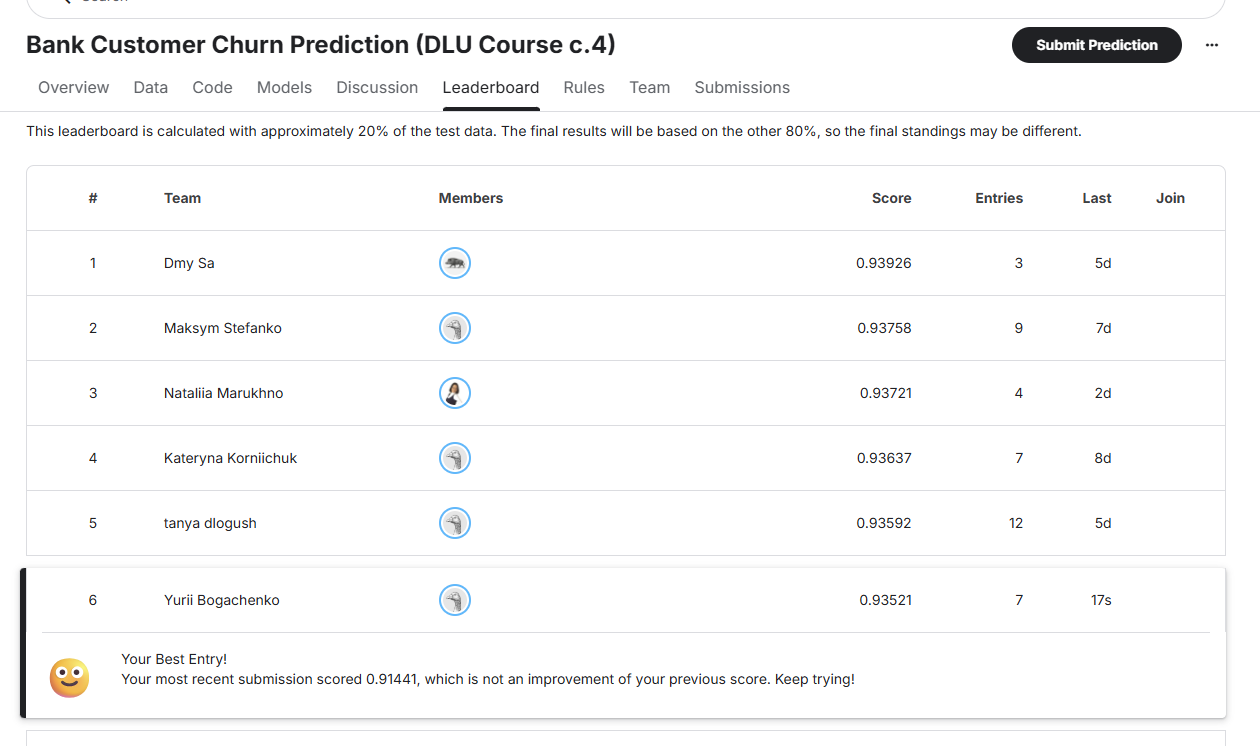